# Traffic benchmark: 3. Confirmatory nested LODO evaluation

This is the sole performance-estimation stage for the adaptive selector. Each outer fold holds out one complete district, evaluates its eligible artificial gaps once, and reports an unweighted macro mean across held-out districts.


## Leakage controls and nested tuning

For a held-out district, hyperparameters are selected only in inner LODO folds among the remaining districts. The local-IQR scale floor is also estimated from the relevant training fold only. Features use observable local context; the artificial gap's truth is never used as a predictor.

This grouping prevents a held-out district from influencing model fitting, tuning, or scale estimation for its outer-fold predictions.


## Pre-specified comparators and interpretation

The selector predicts the candidate-method nRMSE values and selects the method with the lowest predicted error. It is compared with fixed PCHIP and the offline oracle; where included in the result table, the best single fixed method is also reported. The oracle is an unattainable lower bound because it selects after the concealed truth is revealed.

The primary metric is mean held-out nRMSE; lower is better. Comparisons with PCHIP are paired within the same held-out gaps, so a positive improvement favours the selector.


In [1]:
from pathlib import Path
import os
import sys
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'pyproject.toml').is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Start Jupyter from inside the repository.')
    PROJECT_ROOT = PROJECT_ROOT.parent

source_root = str(PROJECT_ROOT / 'src')
if source_root not in sys.path:
    sys.path.insert(0, source_root)
import matplotlib.pyplot as plt
import pandas as pd
from gap_imputation_benchmark.domains.traffic import TRAFFIC_DOMAIN
from gap_imputation_benchmark.evaluation import plot_selected_method_frequency
from gap_imputation_benchmark.paths import load_local_environment, local_path_or_default, project_relative_path_or_label
load_local_environment(override=True)

if not os.environ.get('TRAFFIC_DATA_DIR'):
    raise RuntimeError("Set TRAFFIC_DATA_DIR in .env or in the current session.")

DATA_DIR = Path(os.environ['TRAFFIC_DATA_DIR'])
BENCHMARK_DIR = local_path_or_default(
    'TRAFFIC_BENCHMARK_DIR', PROJECT_ROOT / 'benchmarks' / 'traffic',
)
RESULTS_DIR = local_path_or_default(
    'TRAFFIC_LODO_RESULTS_DIR', PROJECT_ROOT / 'results' / 'traffic' / 'lodo',
)
CONFIG = PROJECT_ROOT / 'configs' / 'traffic_final.toml'
SCRIPT = PROJECT_ROOT / 'scripts' / 'evaluate_traffic_lodo.py'
RESULTS_LOCATION = project_relative_path_or_label(
    RESULTS_DIR, fallback_label='configured evaluation directory'
)
print(f'Results output: {RESULTS_LOCATION}')


Results output: results/traffic/lodo


## Run the frozen evaluation

The canonical command reads the benchmark, frozen configuration, and any required external data. It writes one self-contained results directory and does not silently replace reviewed outputs. Use a new configured results path for an intentional rerun.


In [2]:
import subprocess

execution_env = os.environ.copy()
execution_env['PYTHONPATH'] = source_root + os.pathsep + execution_env.get('PYTHONPATH', '')
command = [
    sys.executable, str(SCRIPT), '--config', str(CONFIG), '--data-dir', str(DATA_DIR),
    '--benchmark-dir', str(BENCHMARK_DIR), '--results-dir', str(RESULTS_DIR),
]
subprocess.run(command, cwd=PROJECT_ROOT, env=execution_env, check=True)
print(f'Evaluation outputs written to: {RESULTS_LOCATION}')


Traffic LODO results written: lodo (9,997 predictions)
Evaluation outputs written to: results/traffic/lodo


## Outer-fold results and inner-fold tuning record

`lodo_summary.csv` contains one row per held-out district plus the unweighted macro mean. `lodo_hyperparameter_tuning.csv` documents candidate scores within each outer fold, making the selected configuration auditable.

The prediction table should contain one row per eligible held-out gap. Any difference from the requested benchmark count must be traced to explicit method-applicability or exclusion records before aggregate results are interpreted.


In [5]:
summary = pd.read_csv(RESULTS_DIR / 'lodo_summary.csv')
tuning = pd.read_csv(RESULTS_DIR / 'lodo_hyperparameter_tuning.csv')
display(summary)
display(tuning.groupby('outer_target_district', group_keys=False).head(1))


,district,n_gaps,mean_selected_nrmse,mean_pchip_nrmse,mean_general_oracle_nrmse,mean_oracle_nrmse,mean_regret_vs_oracle_nrmse,oracle_match_rate,absolute_improvement_vs_pchip_nrmse,relative_improvement_vs_pchip_percent
0,3,2499,0.484677,0.690763,0.617926,0.359363,0.125314,0.511405,0.206086,29.834546
1,4,2500,0.418081,0.619077,0.552427,0.308815,0.109266,0.510800,0.200996,32.467002
2,7,2500,0.453783,0.677965,0.566324,0.333717,0.120065,0.524000,0.224182,33.066898
3,11,2498,0.428901,0.641435,0.538938,0.322473,0.106428,0.532826,0.212534,33.134150
4,macro_mean_across_districts,9997,0.446361,0.657310,0.568904,0.331092,0.115269,0.519758,0.210949,32.125649


,outer_target_district,candidate_index,n_estimators,min_samples_leaf,max_depth,max_features,inner_lodo_mean_selected_nrmse
0,3,2,400,5,NaN,sqrt,0.433746
3,4,3,300,10,NaN,1.0,0.453055
6,7,3,300,10,NaN,1.0,0.443405
9,11,2,400,5,NaN,sqrt,0.451314


## Macro comparison and method-selection behaviour

The macro comparison gives every held-out district equal weight; it does not pool units by their number of gaps. The selected-method panel summarises only held-out predictions. Selection frequency is a behavioural diagnostic, not evidence of superiority on its own.

Together with the per-fold table, these outputs support review of both aggregate performance and heterogeneity across districts.


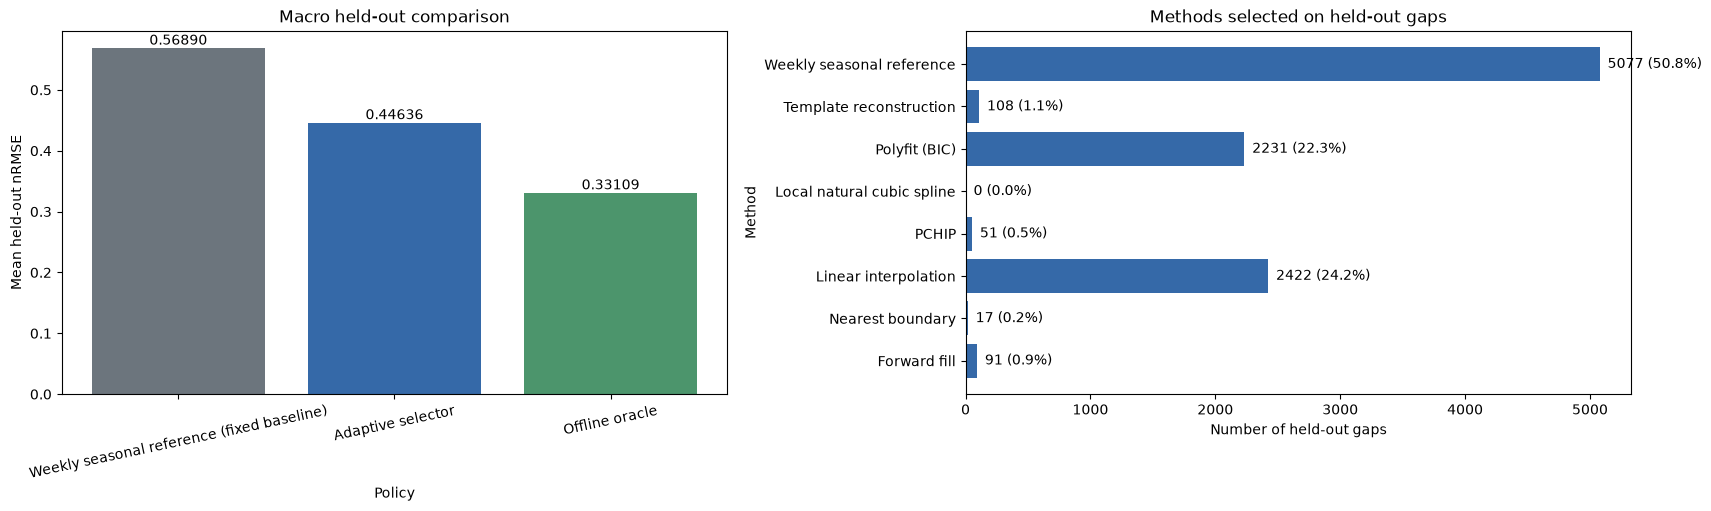

,mean_nrmse,improvement_vs_fixed_baseline_percent
Weekly seasonal reference (fixed baseline),0.56890,0.00000
Adaptive selector,0.44636,21.54025
Offline oracle,0.33109,41.80178


,count,share
selected_method,,
forward_fill,9100,0.9
nearest_boundary,1700,0.2
linear,242200,24.2
pchip,5100,0.5
local_natural_cubic_spline,0,0.0
polyfit_bic,223100,22.3
template,10800,1.1
seasonal_periodic,507700,50.8


In [7]:
selected_method_counts = pd.read_csv(RESULTS_DIR / 'lodo_selected_method_counts.csv')
predictions = pd.read_csv(RESULTS_DIR / 'lodo_gap_predictions.csv')

macro_row = summary.loc[
    summary['district'].astype(str).str.startswith('macro_mean_')
].iloc[0]

fixed_columns = [
    f'actual_{method}_nrmse'
    for method in TRAFFIC_DOMAIN.methods
]

fixed_scores = (
    predictions
    .groupby('district')[fixed_columns]
    .mean()
    .mean()
    .sort_values()
)

best_fixed_column = fixed_scores.index[0]
best_fixed_method = (
    best_fixed_column
    .removeprefix('actual_')
    .removesuffix('_nrmse')
)
best_fixed_nrmse = fixed_scores.iloc[0]

best_fixed_label = TRAFFIC_DOMAIN.method_labels.get(
    best_fixed_method,
    best_fixed_method,
)

macro_comparison = pd.Series({
    f'{best_fixed_label} (fixed baseline)': best_fixed_nrmse,
    'Adaptive selector': macro_row['mean_selected_nrmse'],
    'Offline oracle': macro_row['mean_oracle_nrmse'],
})

improvement_vs_fixed_percent = 100 * (
    best_fixed_nrmse - macro_row['mean_selected_nrmse']
) / best_fixed_nrmse

oracle_improvement_vs_fixed_percent = 100 * (
    best_fixed_nrmse - macro_row['mean_oracle_nrmse']
) / best_fixed_nrmse

fig, axes = plt.subplots(1, 2, figsize=(17, 5), constrained_layout=True)

bars = axes[0].bar(
    macro_comparison.index,
    macro_comparison.values,
    color=('#6c757d', '#3569a8', '#4c956c'),
)
axes[0].set(
    title='Macro held-out comparison',
    xlabel='Policy',
    ylabel='Mean held-out nRMSE',
)
axes[0].tick_params(axis='x', rotation=12)

for bar, value in zip(bars, macro_comparison.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.5f}',
        ha='center',
        va='bottom',
    )

_, selected_method_summary = plot_selected_method_frequency(
    selected_method_counts,
    TRAFFIC_DOMAIN.methods,
    method_labels=TRAFFIC_DOMAIN.method_labels,
    ax=axes[1],
)

plt.show()

comparison_table = macro_comparison.rename('mean_nrmse').to_frame()
comparison_table['improvement_vs_fixed_baseline_percent'] = [
    0.0,
    improvement_vs_fixed_percent,
    oracle_improvement_vs_fixed_percent,
]

display(comparison_table.round(5))
display((100 * selected_method_summary).round(1))